# 🧠 RSNA Intracranial Aneurysm Detection — Classical ML Pipeline

**Approach:** Candidate-level binary classification to distinguish true aneurysms from false positives.  
**Data:** Hand-crafted radiomics features extracted from candidate regions in 3D CTA/MRA scans.  
**Key constraint:** Patient-level splits to avoid data leakage.

---
### Pipeline Overview
1. Install & Import
2. Load Data
3. Exploratory Data Analysis (EDA)
4. PCA & ICA — Dimensionality Reduction & Visualization
5. Preprocessing & Patient-Level Split
6. Handle Class Imbalance
7. Train & Compare Models — LR, RF, XGBoost, LightGBM, SVM (raw + PCA + ICA variants)
8. Evaluate Best Model (AUC-ROC, AUC-PR, FROC)
9. Threshold Tuning
10. SHAP Feature Importance
11. All Models Comparison
12. Save Best Model

## 1. Install & Import

In [ ]:
# Install required packages (Colab)
!pip install -q xgboost lightgbm shap imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import joblib

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("All imports successful ✅")

All imports successful ✅


## 2. Load Data

> Upload your `features_selected.csv` when prompted, or place it in your Google Drive and mount it.

In [ ]:
# ── Option A: Upload directly ──────────────────────────────────────────────────
from google.colab import files
#uploaded = files.upload()   # Select features_selected.csv
#CSV_PATH = list(uploaded.keys())[0]

# ── Option B: Google Drive (comment out Option A and uncomment below) ──────────
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/features_selected.csv'

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (59479, 22)


,case_id,label,meta_candidate_id,meta_method,v_skewness,spatial_z_mm,v_coeff_var,shape_bbox_dz_mm,spatial_y_mm,spatial_x_mm,...,v_p75,v_entropy,shape_bbox_dx_mm,spatial_dist_edge_mm,shape_compactness,v_p90,tex_glcm_proxy_energy,v_iqr,v_range,shape_equiv_diam_mm
0,1.2.826.0.1.3680043.8.498.12497051706237588977...,0,1,threshold_cc,1.423109,0.794118,0.224972,2.5,50.852941,17.823529,...,0.233478,2.773840,1.0,0.794118,0.032407,0.288265,0.000,0.034065,0.162828,1.186688
1,1.2.826.0.1.3680043.8.498.12497051706237588977...,0,3,threshold_cc,0.521303,2.183099,0.259893,3.5,51.485915,116.408451,...,0.302349,5.411705,3.5,2.183099,0.002004,0.350801,0.250,0.110689,0.269199,2.190053
2,1.2.826.0.1.3680043.8.498.12497051706237588977...,0,4,threshold_cc,0.801295,0.826087,0.448740,2.0,72.934783,32.195652,...,0.388287,3.769644,3.5,0.826087,0.029297,0.585311,0.000,0.175049,0.500387,1.529916
3,1.2.826.0.1.3680043.8.498.12497051706237588977...,0,5,threshold_cc,1.070953,1.171875,0.166519,3.5,73.359375,62.390625,...,0.210275,4.980908,3.0,1.171875,0.093294,0.229403,0.250,0.040665,0.131965,1.969490
4,1.2.826.0.1.3680043.8.498.12497051706237588977...,0,6,threshold_cc,1.719372,23.242376,0.443299,50.0,88.567525,73.220594,...,0.333141,10.957690,37.0,23.242376,0.002165,0.461540,0.125,0.137472,0.761821,8.025210


In [ ]:
# Quick sanity checks
print("=" * 50)
print(f"Total candidates : {len(df):,}")
print(f"Unique patients  : {df['case_id'].nunique():,}")
print(f"Positive (label=1): {df['label'].sum():,} ({df['label'].mean()*100:.1f}%)")
print(f"Negative (label=0): {(df['label']==0).sum():,} ({(df['label']==0).mean()*100:.1f}%)")
print(f"Missing values   : {df.isnull().sum().sum()}")
print("=" * 50)
print("\nDetection methods:")
print(df['meta_method'].value_counts())
print("\nCandidates per patient (stats):")
print(df.groupby('case_id').size().describe())

Total candidates : 59,479
Unique patients  : 432
Positive (label=1): 4,440 (7.5%)
Negative (label=0): 55,039 (92.5%)
Missing values   : 0

Detection methods:
meta_method
blob_log        33875
threshold_cc    25604
Name: count, dtype: int64

Candidates per patient (stats):
count    432.000000
mean     137.682870
std       46.268598
min       12.000000
25%      107.000000
50%      134.000000
75%      162.000000
max      383.000000
dtype: float64


## 3. Exploratory Data Analysis (EDA)

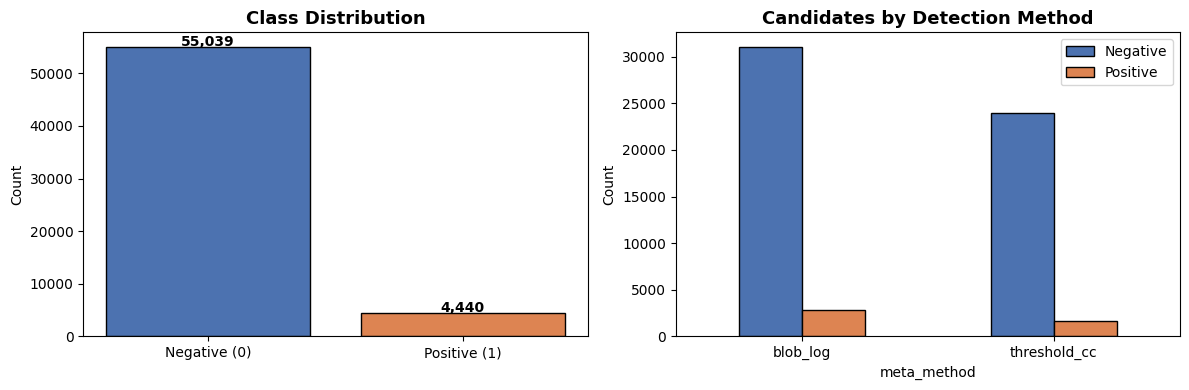

In [ ]:
# ── 3.1 Class Imbalance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['label'].value_counts()
axes[0].bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# By detection method
method_label = df.groupby(['meta_method', 'label']).size().unstack(fill_value=0)
method_label.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'], edgecolor='black', rot=0)
axes[1].set_title('Candidates by Detection Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(['Negative', 'Positive'])

plt.tight_layout()
plt.show()

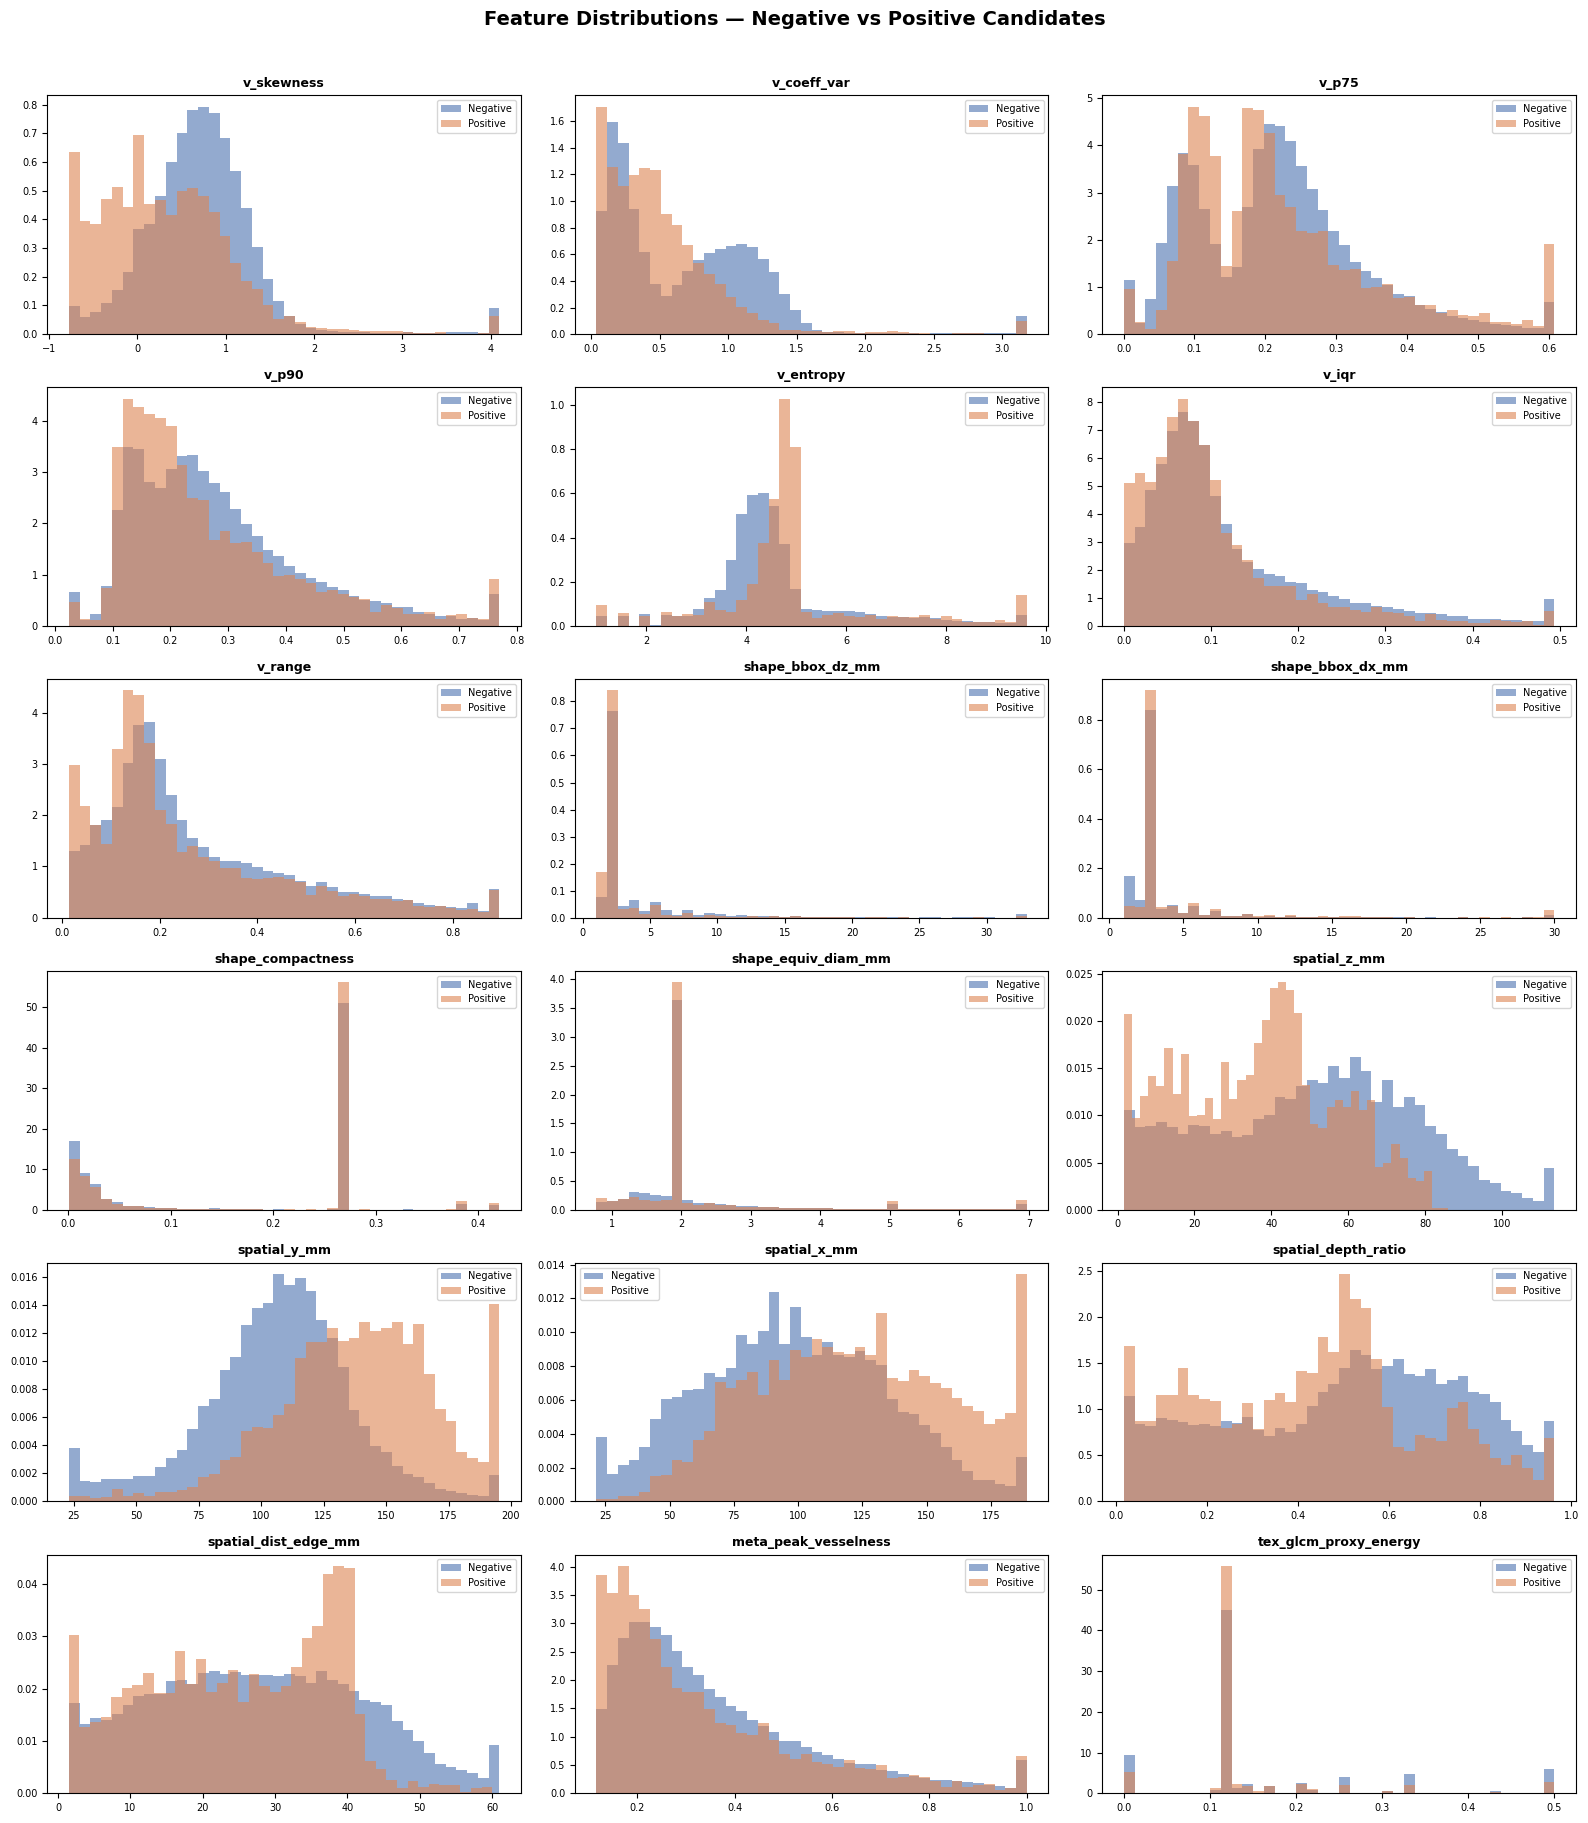

In [ ]:
# ── 3.2 Feature Distributions by Label ────────────────────────────────────────
FEATURE_COLS = [
    'v_skewness', 'v_coeff_var', 'v_p75', 'v_p90', 'v_entropy', 'v_iqr', 'v_range',
    'shape_bbox_dz_mm', 'shape_bbox_dx_mm', 'shape_compactness', 'shape_equiv_diam_mm',
    'spatial_z_mm', 'spatial_y_mm', 'spatial_x_mm', 'spatial_depth_ratio', 'spatial_dist_edge_mm',
    'meta_peak_vesselness', 'tex_glcm_proxy_energy'
]

n_cols = 3
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for label, color, name in [(0, '#4C72B0', 'Negative'), (1, '#DD8452', 'Positive')]:
        axes[i].hist(
            df[df['label'] == label][feat].clip(
                df[feat].quantile(0.01), df[feat].quantile(0.99)
            ),
            bins=40, alpha=0.6, color=color, label=name, density=True
        )
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions — Negative vs Positive Candidates', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

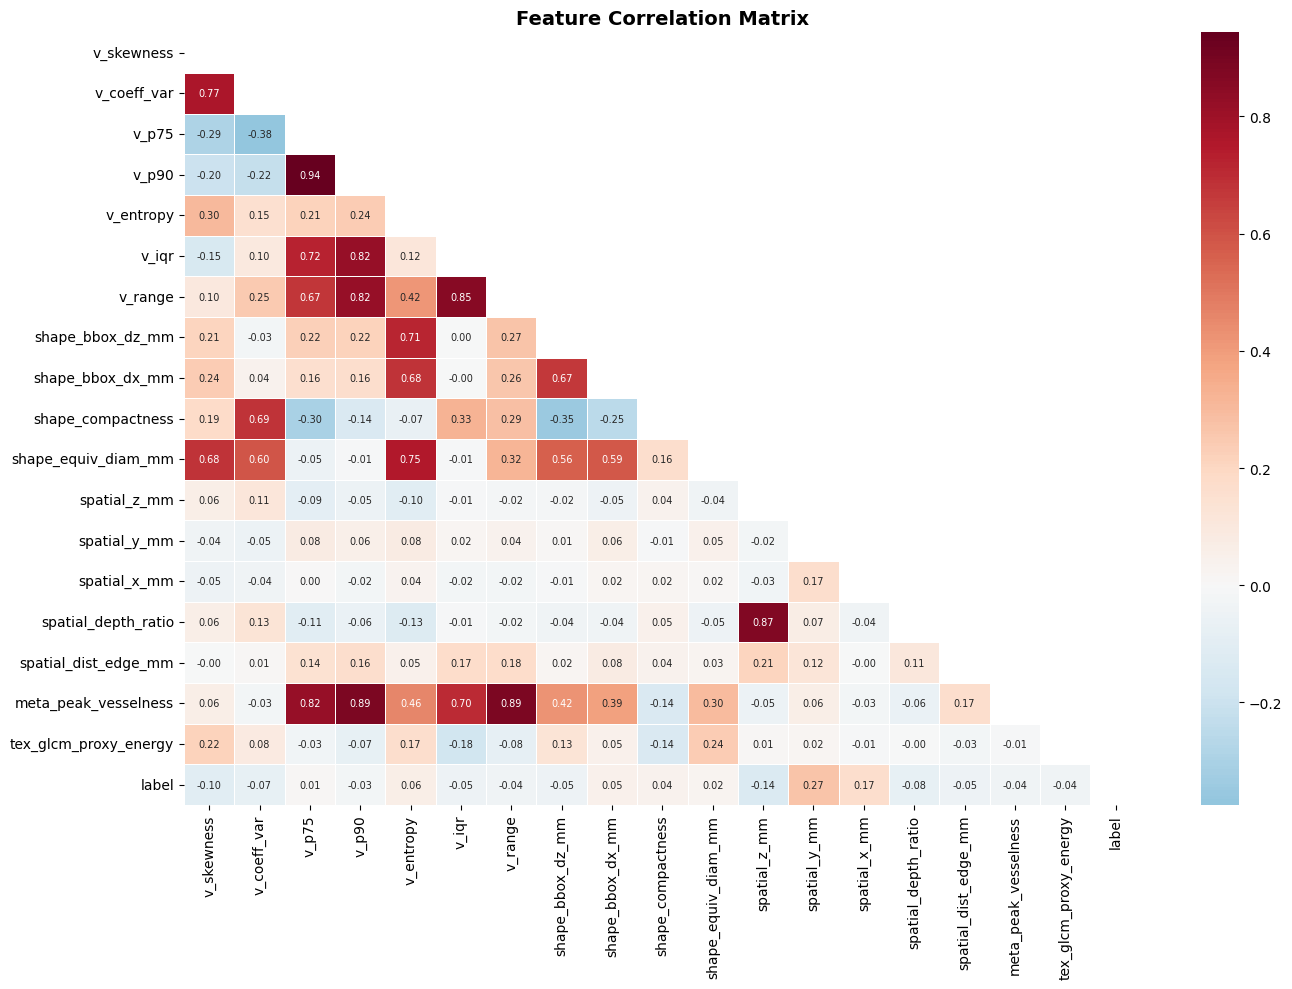

In [ ]:
# ── 3.3 Correlation Heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[FEATURE_COLS + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

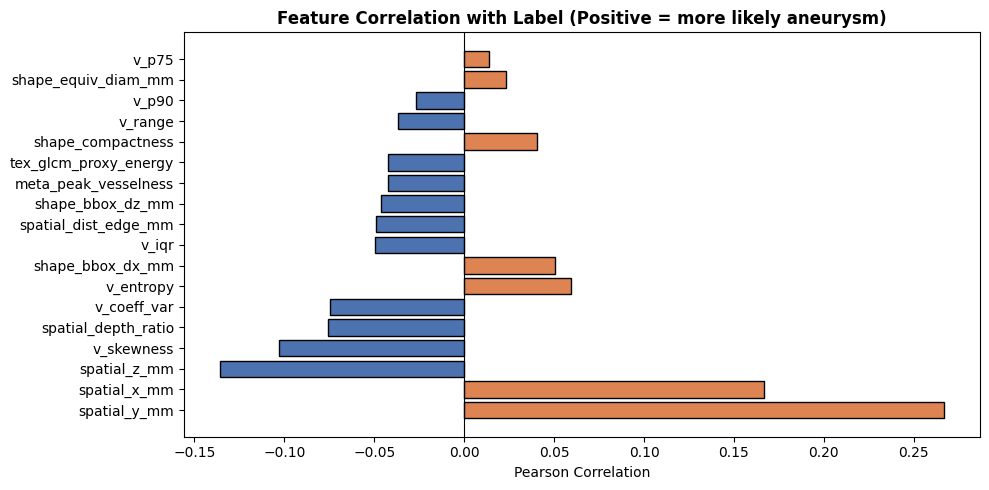

In [ ]:
# ── 3.4 Correlation with Label (sorted) ───────────────────────────────────────
label_corr = df[FEATURE_COLS].corrwith(df['label']).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DD8452' if v > 0 else '#4C72B0' for v in label_corr]
ax.barh(label_corr.index, label_corr.values, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Label (Positive = more likely aneurysm)', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## 4. PCA & ICA — Dimensionality Reduction & Visualization

**PCA (Principal Component Analysis):** Finds orthogonal axes of maximum variance. Good for reducing correlated features and speeding up models.  
**ICA (Independent Component Analysis):** Goes further — finds statistically *independent* (non-Gaussian) components. Can uncover structure PCA misses, especially in non-linear feature distributions like radiomics.

We'll use them in two ways:
1. **Visualization** — project to 2D and color by label to see class separability
2. **Model input** — compare model performance on raw features vs PCA-transformed vs ICA-transformed

In [ ]:
# ── 4.1 Fit PCA & ICA on training features (scaled) ───────────────────────────
# We define these here so they can be reused in the modeling section
# Note: fit only on train after the split — this is just for EDA visualization,
# so we fit on the full scaled data for now and refit properly after the split.

# Create temporary dataframe with engineered feature
temp_df = df.assign(
    method_blob_log=(df['meta_method'] == 'blob_log').astype(int)
)

# Scale all features
X_all_sc = StandardScaler().fit_transform(
    temp_df[FEATURE_COLS + ['method_blob_log']]
)

y_all = df['label'].values

N_COMPONENTS = 10   # number of PCA/ICA components to keep for modeling

# PCA
pca_viz = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_viz.fit_transform(X_all_sc)

# ICA
ica_viz = FastICA(n_components=2, random_state=SEED, max_iter=500)
X_ica2 = ica_viz.fit_transform(X_all_sc)

print(f"PCA 2-component explained variance: {pca_viz.explained_variance_ratio_.sum()*100:.1f}%")

PCA 2-component explained variance: 43.4%


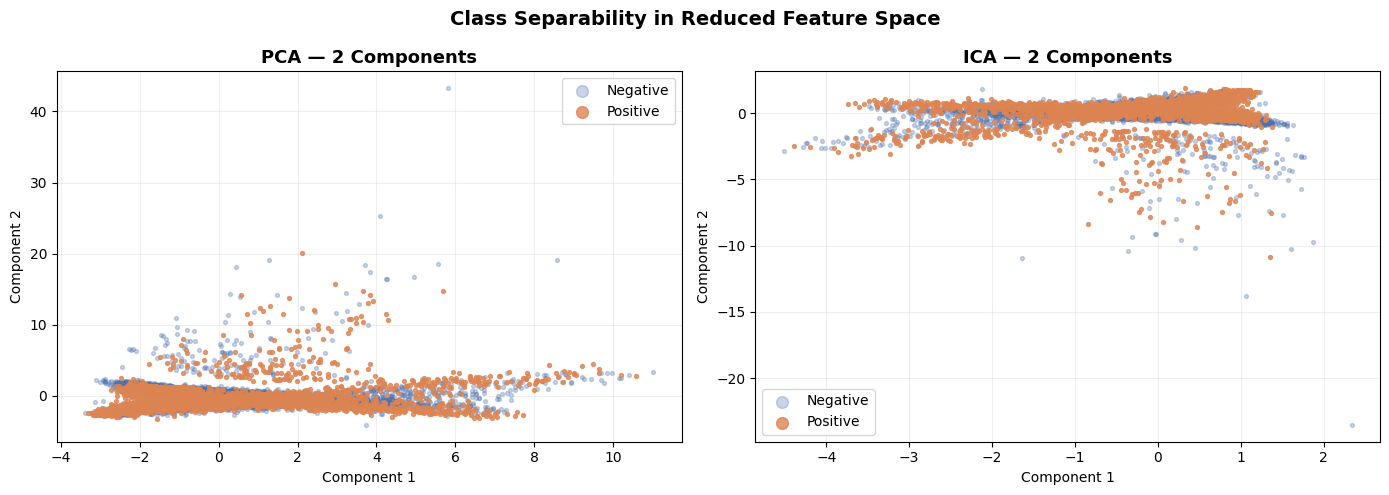

In [ ]:
# ── 4.2 2D Scatter: PCA vs ICA colored by label ───────────────────────────────
# Subsample for plot clarity
plot_n = 5000
idx_neg = np.where(y_all == 0)[0]
idx_pos = np.where(y_all == 1)[0]
plot_idx = np.concatenate([
    np.random.choice(idx_neg, min(plot_n, len(idx_neg)), replace=False),
    np.random.choice(idx_pos, min(plot_n, len(idx_pos)), replace=False)
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X2d, title in [
    (axes[0], X_pca2, 'PCA — 2 Components'),
    (axes[1], X_ica2, 'ICA — 2 Components'),
]:
    for label, color, name, alpha, zorder in [
        (0, '#4C72B0', 'Negative', 0.3, 1),
        (1, '#DD8452', 'Positive', 0.8, 2)
    ]:
        mask = y_all[plot_idx] == label
        ax.scatter(
            X2d[plot_idx][mask, 0], X2d[plot_idx][mask, 1],
            c=color, label=name, alpha=alpha, s=8, zorder=zorder
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(markerscale=3)
    ax.grid(True, alpha=0.2)

plt.suptitle('Class Separability in Reduced Feature Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

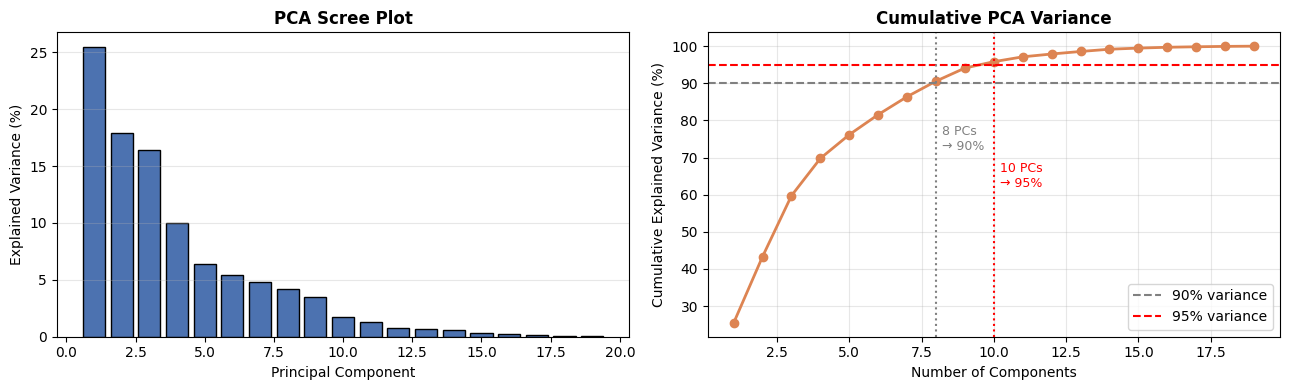

Components to reach 90% variance: 8
Components to reach 95% variance: 10
We will use N_COMPONENTS=10 for PCA/ICA in modeling


In [ ]:
# ── 4.3 PCA Explained Variance Curve ─────────────────────────────────────────
pca_full = PCA(random_state=SEED).fit(X_all_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100, color='#4C72B0', edgecolor='black')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#DD8452', lw=2)
axes[1].axhline(90, color='gray', linestyle='--', label='90% variance')
axes[1].axhline(95, color='red',  linestyle='--', label='95% variance')
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
axes[1].axvline(n_90, color='gray', linestyle=':', lw=1.5)
axes[1].axvline(n_95, color='red',  linestyle=':', lw=1.5)
axes[1].text(n_90 + 0.2, 72, f'{n_90} PCs\n→ 90%', color='gray', fontsize=9)
axes[1].text(n_95 + 0.2, 62, f'{n_95} PCs\n→ 95%', color='red',  fontsize=9)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative PCA Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Components to reach 90% variance: {n_90}")
print(f"Components to reach 95% variance: {n_95}")
print(f"We will use N_COMPONENTS={N_COMPONENTS} for PCA/ICA in modeling")

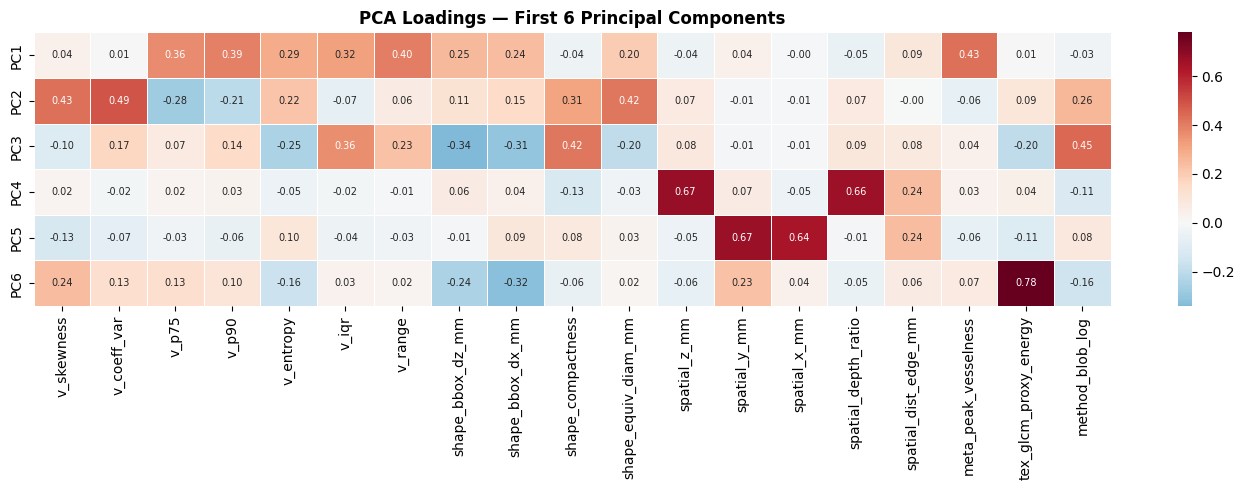

In [ ]:
# ── 4.4 PCA Loadings — which original features dominate each PC? ───────────────
feature_names_all = FEATURE_COLS + ['method_blob_log']
loadings = pd.DataFrame(
    pca_full.components_[:6],
    columns=feature_names_all,
    index=[f'PC{i+1}' for i in range(6)]
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('PCA Loadings — First 6 Principal Components', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Preprocessing & Patient-Level Split

> **Why patient-level split?**  
> Each patient contributes hundreds of candidates. A random row-level split would put candidates from the same patient in both train and test — the model would "remember" that patient and give inflated metrics. We split by `case_id` so no patient leaks across sets.

In [ ]:
# ── 5.1 Encode meta_method ────────────────────────────────────────────────────
df['method_blob_log'] = (df['meta_method'] == 'blob_log').astype(int)

ALL_FEATURES = FEATURE_COLS + ['method_blob_log']

X = df[ALL_FEATURES].values
y = df['label'].values
groups = df['case_id'].values   # for GroupKFold

print(f"Feature matrix shape: {X.shape}")
print(f"Features used: {ALL_FEATURES}")

Feature matrix shape: (59479, 19)
Features used: ['v_skewness', 'v_coeff_var', 'v_p75', 'v_p90', 'v_entropy', 'v_iqr', 'v_range', 'shape_bbox_dz_mm', 'shape_bbox_dx_mm', 'shape_compactness', 'shape_equiv_diam_mm', 'spatial_z_mm', 'spatial_y_mm', 'spatial_x_mm', 'spatial_depth_ratio', 'spatial_dist_edge_mm', 'meta_peak_vesselness', 'tex_glcm_proxy_energy', 'method_blob_log']


In [ ]:
# ── 5.2 Patient-Level Train/Test Split (80/20 by patient) ─────────────────────
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"Train: {len(X_train):,} candidates | {len(np.unique(groups_train))} patients")
print(f"Test : {len(X_test):,} candidates  | {len(np.unique(groups[test_idx]))} patients")
print(f"Train positive rate: {y_train.mean()*100:.1f}%")
print(f"Test  positive rate: {y_test.mean()*100:.1f}%")

Train: 47,492 candidates | 345 patients
Test : 11,987 candidates  | 87 patients
Train positive rate: 7.4%
Test  positive rate: 7.8%


In [ ]:
# ── 5.3 Feature Scaling ───────────────────────────────────────────────────────
# Fit scaler ONLY on train, apply to both (no leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Scaler fitted on training data only ✅")

Scaler fitted on training data only ✅


In [ ]:
# ── 5.4 Fit PCA & ICA on training set — transform both train and test ──────────
# Important: fit ONLY on X_train_sc, then transform test — no leakage

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

ica = FastICA(n_components=N_COMPONENTS, random_state=SEED, max_iter=1000, tol=0.01)
X_train_ica = ica.fit_transform(X_train_sc)
X_test_ica  = ica.transform(X_test_sc)

print(f"PCA train shape : {X_train_pca.shape}")
print(f"ICA train shape : {X_train_ica.shape}")
print(f"PCA explained variance ({N_COMPONENTS} components): {pca.explained_variance_ratio_.sum()*100:.1f}%")
print("PCA and ICA fitted on training data only ✅")

PCA train shape : (47492, 10)
ICA train shape : (47492, 10)
PCA explained variance (10 components): 95.7%
PCA and ICA fitted on training data only ✅


## 6. Handle Class Imbalance

We'll use two strategies:
- **Strategy A:** `class_weight='balanced'` inside each model (reweights the loss)
- **Strategy B:** SMOTE oversampling on training data only

We'll compare both during cross-validation.

In [ ]:
# SMOTE — fit on training set only
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"After SMOTE — Train shape : {X_train_sm.shape}")
print(f"Class balance after SMOTE: {np.bincount(y_train_sm)}")

After SMOTE — Train shape : (87962, 19)
Class balance after SMOTE: [43981 43981]


## 7. Train & Compare Models

We use **GroupKFold (5-fold)** cross-validation on the training set, grouped by `case_id`, so folds respect patient boundaries.

We test **three input variants** for each model family:
- **Raw** — all 19 scaled features
- **PCA** — 10 principal components
- **ICA** — 10 independent components

SVM in particular benefits from dimensionality reduction since it scales poorly with many features.

In [ ]:
# ── 7.1 Define Models ─────────────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGB/LGBM: {scale_pos_weight:.1f}")

# Raw-feature models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=SEED
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, scale_pos_weight=scale_pos_weight,
        max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', use_label_encoder=False,
        n_jobs=-1, random_state=SEED, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, scale_pos_weight=scale_pos_weight,
        max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=SEED, verbose=-1
    ),
    # SVM on raw features — RBF kernel, balanced weights
    'SVM (Raw)': SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=SEED
    ),
}

# SVM on PCA-reduced features — SVM scales better in lower dims
models_pca = {
    'SVM + PCA': SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=SEED
    ),
    'SVM + ICA': SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=SEED
    ),
    'LR + PCA': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED, C=1.0
    ),
    'LR + ICA': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=SEED, C=1.0
    ),
}

# Map each transformed-space model to its input data
pca_ica_inputs = {
    'SVM + PCA': (X_train_pca, X_test_pca),
    'SVM + ICA': (X_train_ica, X_test_ica),
    'LR + PCA' : (X_train_pca, X_test_pca),
    'LR + ICA' : (X_train_ica, X_test_ica),
}

print("Models defined ✅")

scale_pos_weight for XGB/LGBM: 12.5
Models defined ✅


In [ ]:
# ── 7.2 GroupKFold Cross-Validation — Raw feature models ─────────────────────
gkf = GroupKFold(n_splits=5)
cv_results = {}

scoring = ['roc_auc', 'average_precision']

print("Running 5-fold GroupKFold CV on RAW features...\n")
for name, model in models.items():
    print(f"  ▶ {name}...", end=" ", flush=True)
    cv = cross_validate(
        model, X_train_sc, y_train,
        cv=gkf.split(X_train_sc, y_train, groups=groups_train),
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {
        'AUC-ROC mean' : cv['test_roc_auc'].mean(),
        'AUC-ROC std'  : cv['test_roc_auc'].std(),
        'AUC-PR mean'  : cv['test_average_precision'].mean(),
        'AUC-PR std'   : cv['test_average_precision'].std(),
        'Input'        : 'Raw'
    }
    print(f"AUC-ROC={cv['test_roc_auc'].mean():.3f} | AUC-PR={cv['test_average_precision'].mean():.3f}")

print("\nRunning 5-fold GroupKFold CV on PCA/ICA features...\n")
for name, model in models_pca.items():
    X_cv, _ = pca_ica_inputs[name]
    print(f"  ▶ {name}...", end=" ", flush=True)
    cv = cross_validate(
        model, X_cv, y_train,
        cv=gkf.split(X_cv, y_train, groups=groups_train),
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    space = 'PCA' if 'PCA' in name else 'ICA'
    cv_results[name] = {
        'AUC-ROC mean' : cv['test_roc_auc'].mean(),
        'AUC-ROC std'  : cv['test_roc_auc'].std(),
        'AUC-PR mean'  : cv['test_average_precision'].mean(),
        'AUC-PR std'   : cv['test_average_precision'].std(),
        'Input'        : space
    }
    print(f"AUC-ROC={cv['test_roc_auc'].mean():.3f} | AUC-PR={cv['test_average_precision'].mean():.3f}")

cv_df = pd.DataFrame(cv_results).T
cv_df[['AUC-ROC mean','AUC-ROC std','AUC-PR mean','AUC-PR std']] = \
    cv_df[['AUC-ROC mean','AUC-ROC std','AUC-PR mean','AUC-PR std']].astype(float).round(4)
print("\n── Cross-Validation Summary ─────────────────────")
print(cv_df.to_string())

Running 5-fold GroupKFold CV on RAW features...

  ▶ Logistic Regression... AUC-ROC=0.890 | AUC-PR=0.378
  ▶ Random Forest... AUC-ROC=0.918 | AUC-PR=0.445
  ▶ XGBoost... AUC-ROC=0.926 | AUC-PR=0.454
  ▶ LightGBM... AUC-ROC=0.925 | AUC-PR=0.450
  ▶ SVM (Raw)... AUC-ROC=0.916 | AUC-PR=0.403

Running 5-fold GroupKFold CV on PCA/ICA features...

  ▶ SVM + PCA... AUC-ROC=0.915 | AUC-PR=0.414
  ▶ SVM + ICA... AUC-ROC=0.913 | AUC-PR=0.409
  ▶ LR + PCA... AUC-ROC=0.837 | AUC-PR=0.347
  ▶ LR + ICA... AUC-ROC=0.837 | AUC-PR=0.347

── Cross-Validation Summary ─────────────────────
                     AUC-ROC mean  AUC-ROC std  AUC-PR mean  AUC-PR std Input
Logistic Regression        0.8903       0.0275       0.3777      0.1678   Raw
Random Forest              0.9181       0.0197       0.4455      0.1682   Raw
XGBoost                    0.9261       0.0188       0.4536      0.1700   Raw
LightGBM                   0.9251       0.0189       0.4498      0.1726   Raw
SVM (Raw)                  0.9165

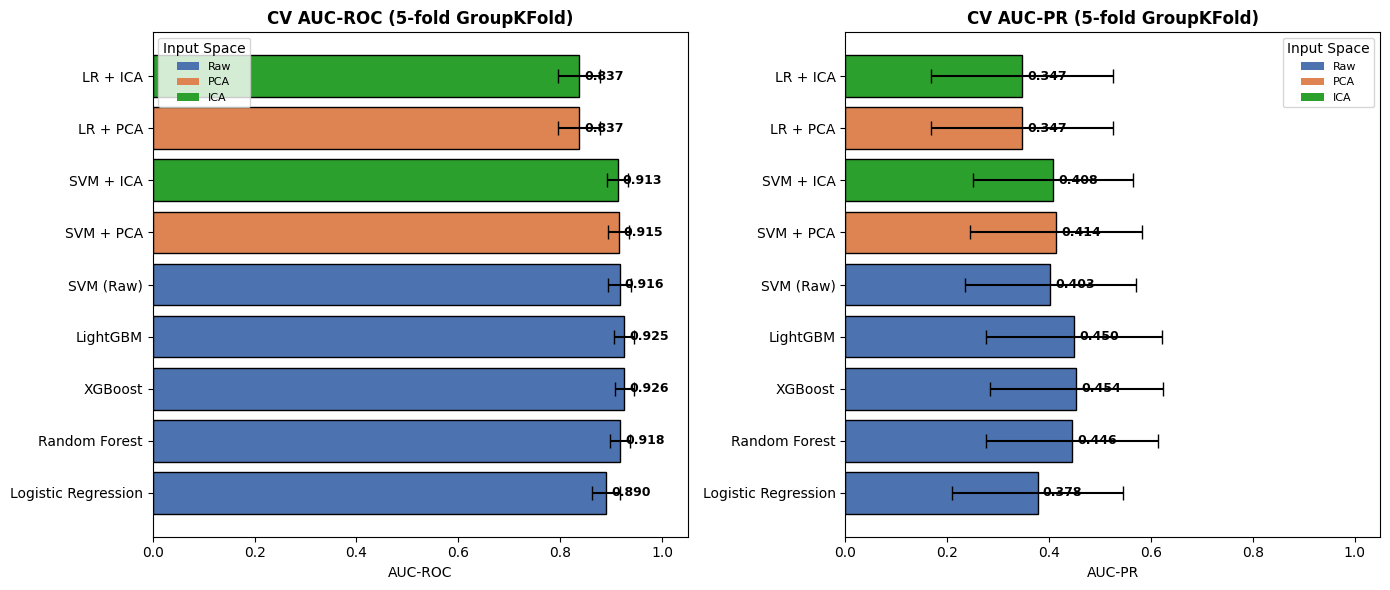

In [ ]:
# ── 7.3 CV Results Plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_map = {'Raw': '#4C72B0', 'PCA': '#DD8452', 'ICA': '#2ca02c'}
bar_colors = [color_map[i] for i in cv_df['Input']]

for ax, metric, col_mean, col_std in [
    (axes[0], 'AUC-ROC', 'AUC-ROC mean', 'AUC-ROC std'),
    (axes[1], 'AUC-PR',  'AUC-PR mean',  'AUC-PR std'),
]:
    means = cv_df[col_mean].astype(float)
    stds  = cv_df[col_std].astype(float)
    bars = ax.barh(means.index, means.values, xerr=stds.values,
                   color=bar_colors, edgecolor='black', capsize=5)
    ax.set_xlim(0, 1.05)
    ax.set_title(f'CV {metric} (5-fold GroupKFold)', fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, means.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
    ax.legend(handles=legend_elements, title='Input Space', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Evaluate Best Model on Hold-Out Test Set

We select the best model based on **AUC-PR** (more informative than AUC-ROC for imbalanced problems) and evaluate it on the unseen test set.

In [ ]:
# ── 8.1 Select & Retrain Best Model ───────────────────────────────────────────
best_model_name = cv_df['AUC-PR mean'].astype(float).idxmax()
best_input_space = cv_df.loc[best_model_name, 'Input']
print(f"Best model by AUC-PR : {best_model_name}")
print(f"Input space          : {best_input_space}")

# Select correct model object and data
if best_model_name in models:
    best_model = models[best_model_name]
    X_train_best, X_test_best = X_train_sc, X_test_sc
else:
    best_model = models_pca[best_model_name]
    X_train_best, X_test_best = pca_ica_inputs[best_model_name]

best_model.fit(X_train_best, y_train)

y_prob = best_model.predict_proba(X_test_best)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"\nTest AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Test AUC-PR  : {average_precision_score(y_test, y_prob):.4f}")

Best model by AUC-PR : XGBoost
Input space          : Raw

Test AUC-ROC : 0.9752
Test AUC-PR  : 0.7401


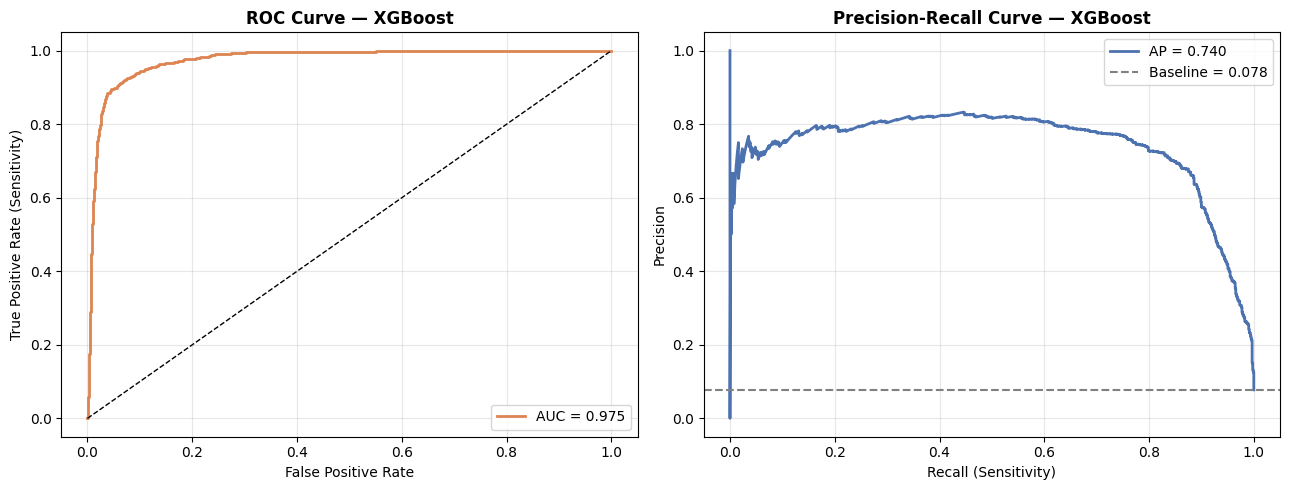

In [ ]:
# ── 8.2 ROC & PR Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_roc = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#DD8452', lw=2, label=f'AUC = {auc_roc:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title(f'ROC Curve — {best_model_name}', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR
prec, rec, _ = precision_recall_curve(y_test, y_prob)
auc_pr = average_precision_score(y_test, y_prob)
baseline = y_test.mean()
axes[1].plot(rec, prec, color='#4C72B0', lw=2, label=f'AP = {auc_pr:.3f}')
axes[1].axhline(baseline, color='gray', linestyle='--', label=f'Baseline = {baseline:.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve — {best_model_name}', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

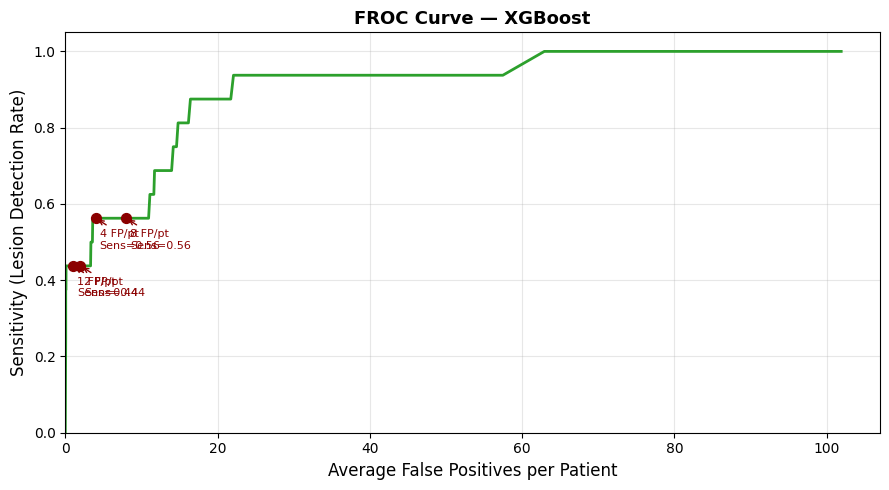

Test patients: 87
Positive patients in test: 16


In [ ]:
# ── 8.3 FROC Curve (Free-Response ROC) ───────────────────────────────────────
# FROC plots Sensitivity vs Average False Positives per Patient
# This is the standard evaluation metric for detection tasks in medical imaging.

# We need patient-level info for test candidates
test_df = df.iloc[test_idx].copy()
test_df['y_prob'] = y_prob

n_test_patients = test_df['case_id'].nunique()

# For each threshold, compute sensitivity and FP/patient
thresholds = np.linspace(0.001, 0.999, 300)
sensitivities, fp_per_patient = [], []

# True positives per patient: at least 1 candidate above threshold where label=1
# False positives: candidates above threshold where label=0
for thresh in thresholds:
    detected = test_df[test_df['y_prob'] >= thresh]

    # Sensitivity = fraction of positive patients detected (at least 1 TP above threshold)
    pos_patients = test_df[test_df['label'] == 1]['case_id'].unique()
    detected_pos_patients = detected[detected['label'] == 1]['case_id'].unique()
    sens = len(detected_pos_patients) / len(pos_patients) if len(pos_patients) > 0 else 0

    # FP per patient
    fp_count = (detected['label'] == 0).sum()
    fp_pp = fp_count / n_test_patients

    sensitivities.append(sens)
    fp_per_patient.append(fp_pp)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fp_per_patient, sensitivities, color='#2ca02c', lw=2)
ax.set_xlabel('Average False Positives per Patient', fontsize=12)
ax.set_ylabel('Sensitivity (Lesion Detection Rate)', fontsize=12)
ax.set_title(f'FROC Curve — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlim(left=0)
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# Mark clinical operating points
for fp_target in [1, 2, 4, 8]:
    idx = np.argmin(np.abs(np.array(fp_per_patient) - fp_target))
    sens_at = sensitivities[idx]
    ax.annotate(
        f'{fp_target} FP/pt\nSens={sens_at:.2f}',
        xy=(fp_per_patient[idx], sens_at),
        xytext=(fp_per_patient[idx] + 0.5, sens_at - 0.08),
        fontsize=8, color='darkred',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=1)
    )
    ax.scatter(fp_per_patient[idx], sens_at, color='darkred', zorder=5, s=50)

plt.tight_layout()
plt.show()

print(f"Test patients: {n_test_patients}")
print(f"Positive patients in test: {len(pos_patients)}")

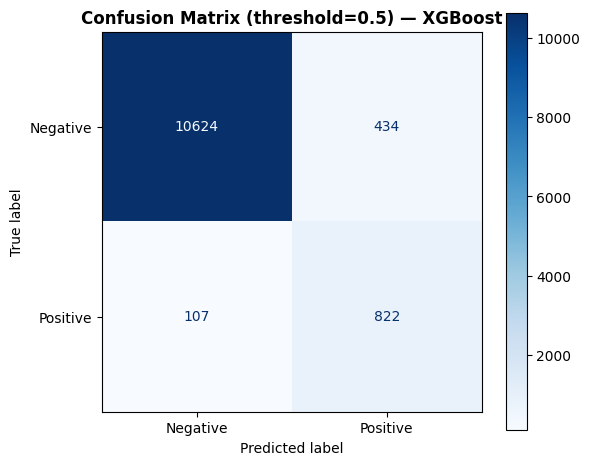


Classification Report (threshold=0.5):
              precision    recall  f1-score   support

    Negative       0.99      0.96      0.98     11058
    Positive       0.65      0.88      0.75       929

    accuracy                           0.95     11987
   macro avg       0.82      0.92      0.86     11987
weighted avg       0.96      0.95      0.96     11987



In [ ]:
# ── 8.4 Confusion Matrix at default threshold ──────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negative', 'Positive'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix (threshold=0.5) — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

## 9. Threshold Tuning

In medical detection, we typically prioritize **high sensitivity** (catch every aneurysm).  
We find the threshold that gives **≥ 90% sensitivity** while keeping FPs as low as possible.

In [ ]:
# ── 9.1 Find Optimal Threshold ────────────────────────────────────────────────
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob)

# F2 score (weights recall 2x more than precision)
f2_scores = (1 + 4) * (prec_arr * rec_arr) / (4 * prec_arr + rec_arr + 1e-9)
best_f2_idx = np.argmax(f2_scores)
best_f2_thresh = thresh_arr[best_f2_idx] if best_f2_idx < len(thresh_arr) else 0.5

# High-sensitivity threshold (≥ 90% recall)
high_sens_mask = rec_arr >= 0.90
if high_sens_mask.sum() > 0:
    high_sens_thresh = thresh_arr[np.where(high_sens_mask)[0][-1]] if np.where(high_sens_mask)[0][-1] < len(thresh_arr) else 0.1
else:
    high_sens_thresh = 0.1

print(f"Best F2 threshold     : {best_f2_thresh:.3f}")
print(f"High sensitivity (≥90%) threshold: {high_sens_thresh:.3f}")

for label, thresh in [('Best F2', best_f2_thresh), ('High Sensitivity', high_sens_thresh)]:
    preds = (y_prob >= thresh).astype(int)
    print(f"\n── {label} (thresh={thresh:.3f}) ──")
    print(classification_report(y_test, preds, target_names=['Negative', 'Positive']))

Best F2 threshold     : 0.508
High sensitivity (≥90%) threshold: 0.400

── Best F2 (thresh=0.508) ──
              precision    recall  f1-score   support

    Negative       0.99      0.96      0.98     11058
    Positive       0.66      0.88      0.76       929

    accuracy                           0.96     11987
   macro avg       0.82      0.92      0.87     11987
weighted avg       0.96      0.96      0.96     11987


── High Sensitivity (thresh=0.400) ──
              precision    recall  f1-score   support

    Negative       0.99      0.94      0.97     11058
    Positive       0.58      0.90      0.70       929

    accuracy                           0.94     11987
   macro avg       0.78      0.92      0.83     11987
weighted avg       0.96      0.94      0.95     11987



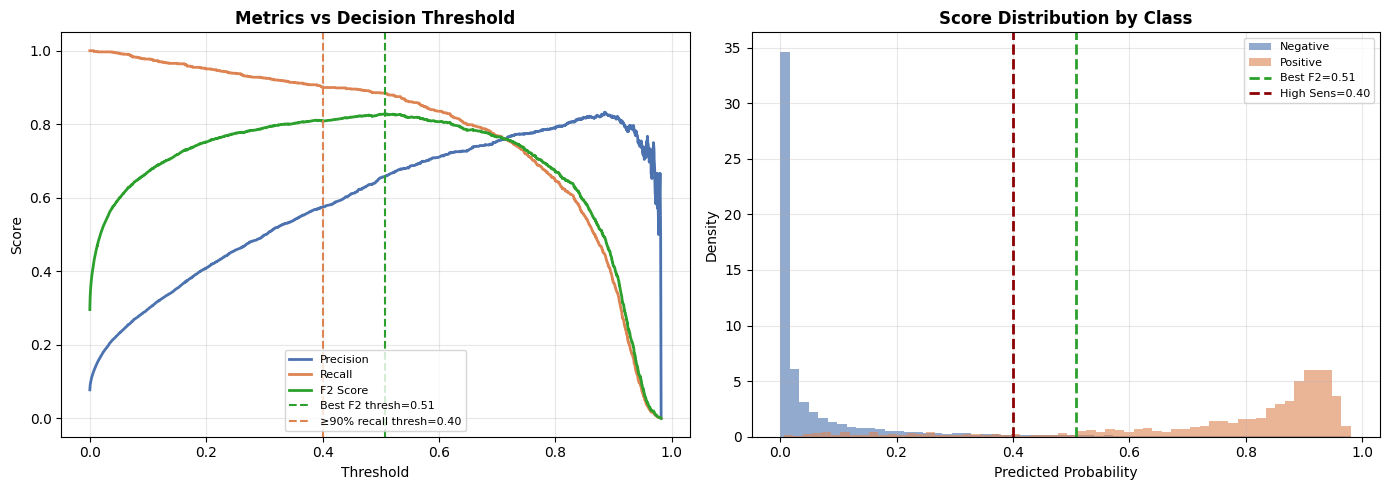

In [ ]:
# ── 9.2 Threshold Plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision & Recall vs Threshold
ax = axes[0]
ax.plot(thresh_arr, prec_arr[:-1], label='Precision', color='#4C72B0', lw=2)
ax.plot(thresh_arr, rec_arr[:-1],  label='Recall',    color='#DD8452', lw=2)
ax.plot(thresh_arr, f2_scores[:-1],label='F2 Score',  color='#2ca02c', lw=2)
ax.axvline(best_f2_thresh,  color='#2ca02c',  linestyle='--', label=f'Best F2 thresh={best_f2_thresh:.2f}')
ax.axvline(high_sens_thresh,color='#DD8452', linestyle='--', label=f'≥90% recall thresh={high_sens_thresh:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Decision Threshold', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Probability distribution
ax = axes[1]
ax.hist(y_prob[y_test == 0], bins=60, alpha=0.6, color='#4C72B0', label='Negative', density=True)
ax.hist(y_prob[y_test == 1], bins=60, alpha=0.6, color='#DD8452', label='Positive', density=True)
ax.axvline(best_f2_thresh,   color='#2ca02c',  linestyle='--', lw=2, label=f'Best F2={best_f2_thresh:.2f}')
ax.axvline(high_sens_thresh, color='darkred',   linestyle='--', lw=2, label=f'High Sens={high_sens_thresh:.2f}')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) tells us **why** the model makes each prediction — which features push a candidate toward positive or negative.

- For **tree-based models** (RF, XGBoost, LightGBM): fast `TreeExplainer`
- For **SVM / Logistic Regression**: `KernelExplainer` on a small sample (slower but model-agnostic)

In [ ]:
# ── 10.1 Compute SHAP Values ────────────────────────────────────────────────────
shap_sample_size = min(1500, len(X_test_best))
np.random.seed(SEED)
shap_idx = np.random.choice(len(X_test_best), shap_sample_size, replace=False)
X_shap = X_test_best[shap_idx]

# Determine feature names for SHAP display
if best_input_space == 'PCA':
    shap_feature_names = [f'PC{i+1}' for i in range(X_shap.shape[1])]
elif best_input_space == 'ICA':
    shap_feature_names = [f'IC{i+1}' for i in range(X_shap.shape[1])]
else:
    shap_feature_names = ALL_FEATURES

# Choose explainer based on model type
tree_models = (XGBClassifier, LGBMClassifier, RandomForestClassifier)

if isinstance(best_model, tree_models):
    print("Using TreeExplainer (fast)...")
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
else:
    print(f"Using KernelExplainer for {best_model_name} (slower — using {shap_sample_size} samples)...")
    # Use small background summary to speed up KernelExplainer
    background = shap.kmeans(X_train_best, 30)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_shap, nsamples=100)

# For binary classifiers, shap_values may be a list [neg_class, pos_class]
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"SHAP computed on {shap_sample_size} test samples ✅")

Using TreeExplainer (fast)...
SHAP computed on 1500 test samples ✅


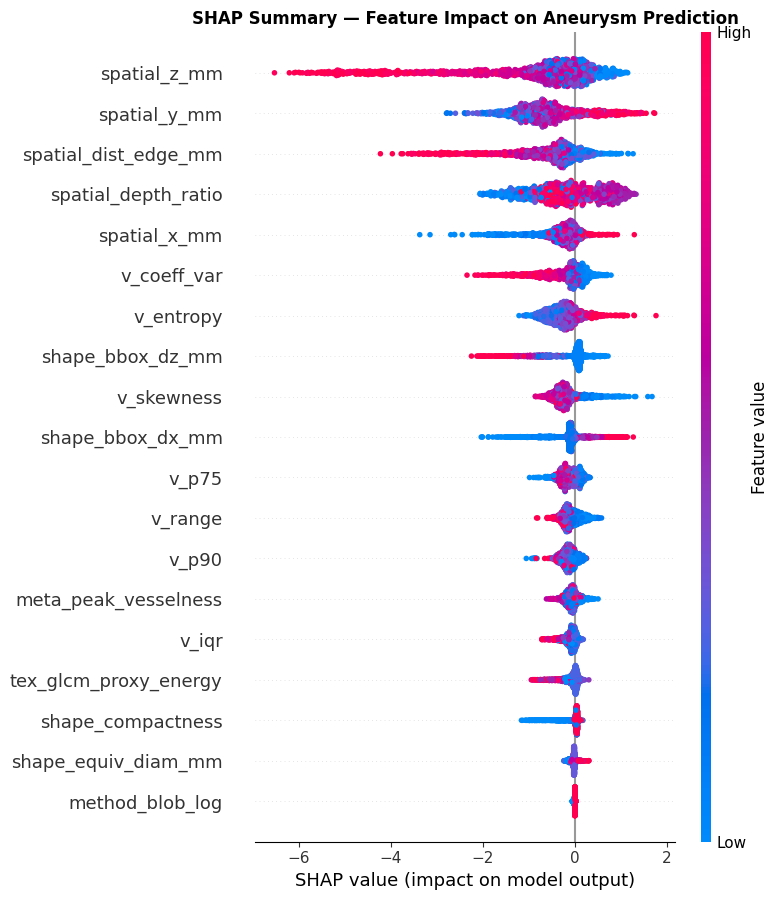

In [ ]:
# ── 10.2 SHAP Summary Plot (Beeswarm) ─────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=shap_feature_names,
    plot_type='dot',
    max_display=len(shap_feature_names),
    show=False
)
plt.title('SHAP Summary — Feature Impact on Aneurysm Prediction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

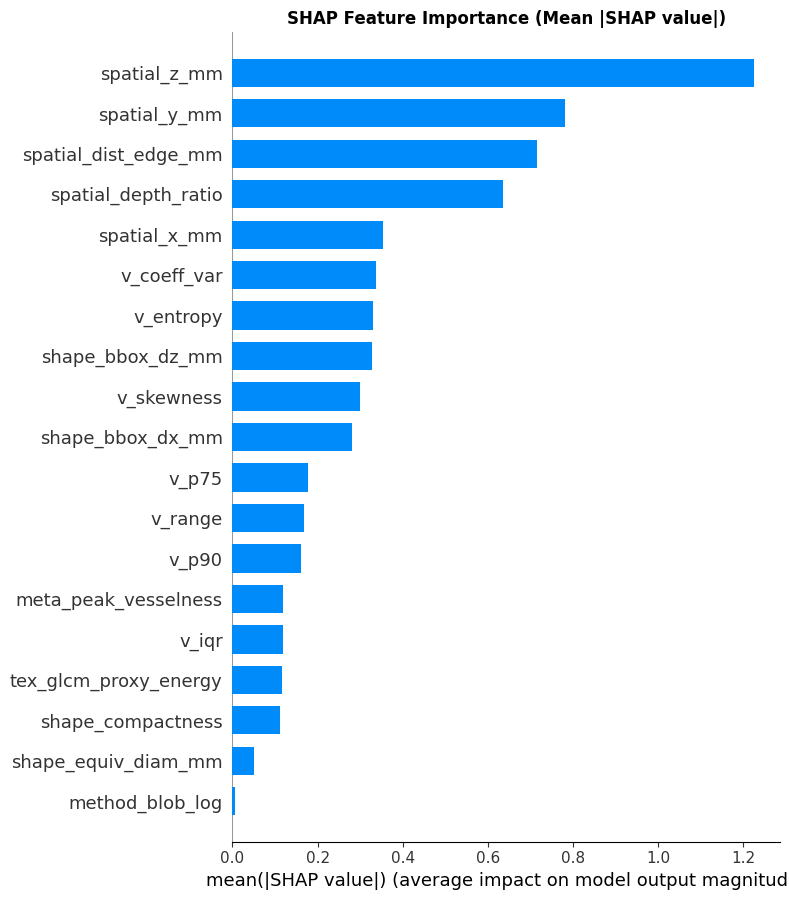

In [ ]:
# ── 10.3 SHAP Bar Plot (Mean |SHAP|) ──────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=shap_feature_names,
    plot_type='bar',
    max_display=len(shap_feature_names),
    show=False
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

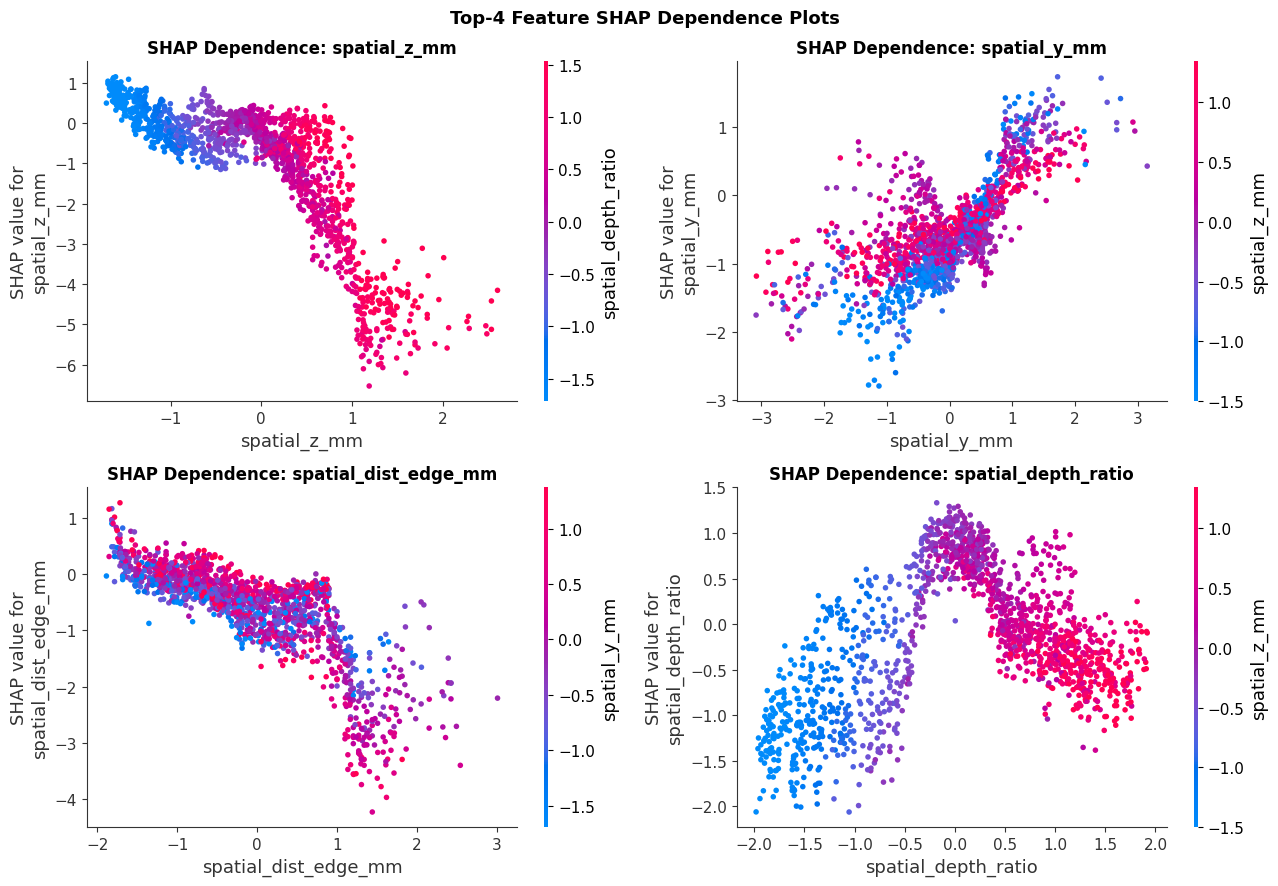

In [ ]:
# ── 10.4 Top Feature SHAP Dependence Plots ─────────────────────────────────────
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_features = np.argsort(mean_abs_shap)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, feat_idx in enumerate(top_features):
    feat_name = shap_feature_names[feat_idx]
    shap.dependence_plot(
        feat_idx, shap_vals, X_shap,
        feature_names=shap_feature_names,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat_name}', fontweight='bold')

plt.suptitle('Top-4 Feature SHAP Dependence Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. All Models Comparison on Test Set

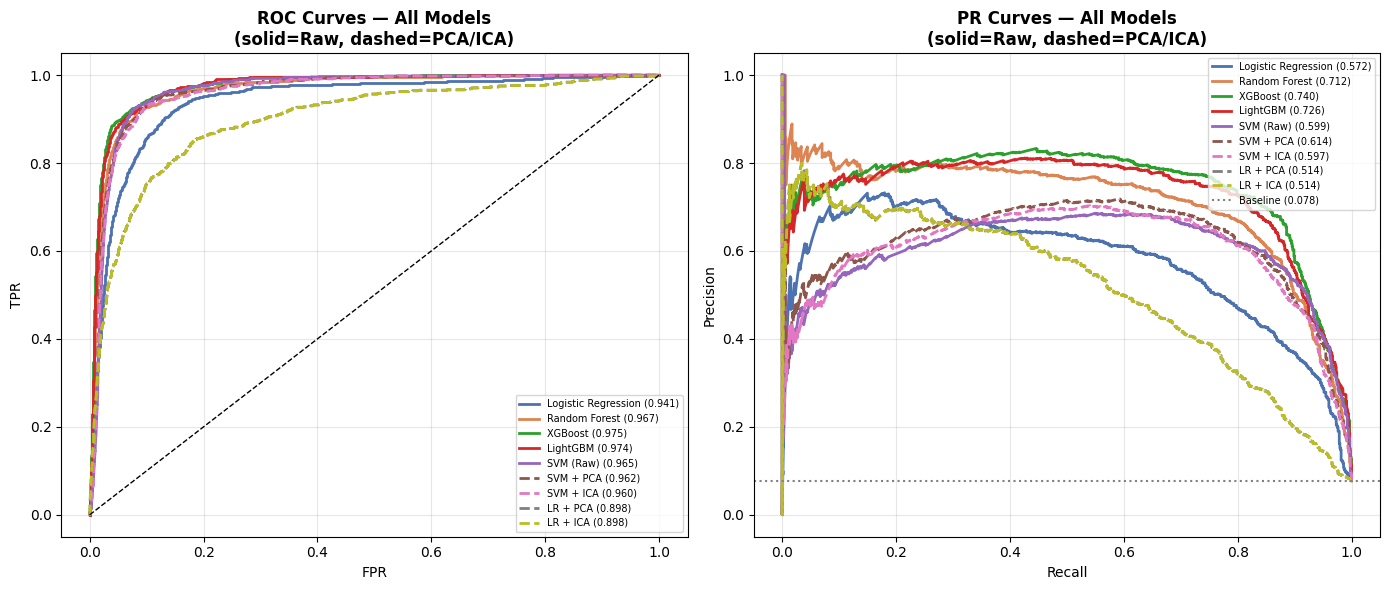


── Final Test Set Results ──────────────────────
                     AUC-ROC  AUC-PR
XGBoost               0.9752  0.7401
LightGBM              0.9739  0.7260
Random Forest         0.9674  0.7115
SVM + PCA             0.9624  0.6144
SVM (Raw)             0.9646  0.5994
SVM + ICA             0.9602  0.5971
Logistic Regression   0.9413  0.5718
LR + ICA              0.8981  0.5143
LR + PCA              0.8981  0.5142


In [ ]:
# ── 11.1 Fit all models and compare ROC/PR curves on test set ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
test_results = {}

all_colors = [
    '#4C72B0', '#DD8452', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22'
]

all_model_items = list(models.items()) + list(models_pca.items())

for (name, model), color in zip(all_model_items, all_colors):
    if name in pca_ica_inputs:
        X_tr, X_te = pca_ica_inputs[name]
    else:
        X_tr, X_te = X_train_sc, X_test_sc

    # Only refit if not already the best model fitted above
    if name != best_model_name:
        model.fit(X_tr, y_train)
    prob = model.predict_proba(X_te)[:, 1]

    auc_r = roc_auc_score(y_test, prob)
    auc_p = average_precision_score(y_test, prob)
    test_results[name] = {'AUC-ROC': auc_r, 'AUC-PR': auc_p}

    fpr, tpr, _ = roc_curve(y_test, prob)
    prec, rec, _ = precision_recall_curve(y_test, prob)

    ls = '--' if name in pca_ica_inputs else '-'
    axes[0].plot(fpr, tpr, color=color, lw=2, linestyle=ls, label=f'{name} ({auc_r:.3f})')
    axes[1].plot(rec, prec, color=color, lw=2, linestyle=ls, label=f'{name} ({auc_p:.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves — All Models\n(solid=Raw, dashed=PCA/ICA)', fontweight='bold')
axes[0].legend(fontsize=7, loc='lower right'); axes[0].grid(True, alpha=0.3)

axes[1].axhline(y_test.mean(), color='gray', linestyle=':', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — All Models\n(solid=Raw, dashed=PCA/ICA)', fontweight='bold')
axes[1].legend(fontsize=7, loc='upper right'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n── Final Test Set Results ──────────────────────")
results_df = pd.DataFrame(test_results).T.round(4).sort_values('AUC-PR', ascending=False)
print(results_df.to_string())

## 11. Save Best Model

In [ ]:
# Save model + scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature list
import json
with open('feature_list.json', 'w') as f:
    json.dump(ALL_FEATURES, f)

print(f"Best model ({best_model_name}) saved to best_model.pkl ✅")
print(f"Scaler saved to scaler.pkl ✅")
print(f"Feature list saved to feature_list.json ✅")

# Download from Colab
from google.colab import files
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('feature_list.json')

Best model (XGBoost) saved to best_model.pkl ✅
Scaler saved to scaler.pkl ✅
Feature list saved to feature_list.json ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Summary

| Step | What we did |
|------|-------------|
| **Split** | Patient-level GroupShuffleSplit (80/20) — no leakage |
| **CV** | 5-fold GroupKFold by `case_id` |
| **Imbalance** | `scale_pos_weight` / `class_weight='balanced'` |
| **Models** | LR, Random Forest, XGBoost, LightGBM |
| **Metrics** | AUC-ROC, AUC-PR, FROC, Confusion Matrix |
| **Threshold** | Tuned for F2 and ≥90% sensitivity |
| **Explainability** | SHAP beeswarm, bar, dependence plots |

> **Next steps to consider:**
> - Hyperparameter tuning with Optuna on GroupKFold
> - Stacking / ensemble of top models
> - Patient-level aggregation: if any candidate in a patient scores above threshold → patient flagged as positive